In [1]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Names from json file:
names_json = ["SM","cQu8","ctu8","cQu1","ctd8","cQlMi","cpQ3","ctlTi","ctG","ctZ","ctW","ctli","ctb8","cbW","cQl3i","cQq13",
              "cptb","ctp","ctei","cpQM","ctlSi", "cQq83","cQq81","ctq1","ctu1","cQei","cQb8","cpt","ctq8","cQd1","cQq11",
              "cQd8","ctd1"]

# All 561 combinations of coefficients (i.e SM,SM; SM,cQu8; cQu8,cQu8; SM,ctu8; cQu8,ctu8; ...)
name_combinations = []
for i in range(len(names_json)):
    for a in range(i+1):
        name_combinations.append([names_json[i],names_json[a]])

In [6]:
# Open file
file = uproot.open("sample_root_files/output_570.root")
# Open events tree
events_tree = file['Events']
# Open EFTFitCoefficients branch:
eft_coeff = events_tree['EFTfitCoefficients'].array()

In [28]:
def coefficient_histogram(branch, cutoff):
    def weights(data):
        return [1 / len(data)] * len(data)
        
   # Different branches require different ways to make a list. Jet pt, we add all terms. Leading leptons pt, we have to do more work...
    if branch == 'Jet_pt':
        jet_pt = events_tree[branch].array()
        sum_of_jet_pt_in_each_event = []
        
        for i in range(len(jet_pt)):
            sum_of_jet_pt_in_each_event.append(sum(jet_pt[i]))
        data1 = np.array(sum_of_jet_pt_in_each_event)

    if branch == 'Two_leading_leptons_pt':
        elec_pt = events_tree['Electron_pt'].array()
        mu_pt = events_tree['Muon_pt'].array()
        tau_pt = events_tree['Tau_pt'].array()
        
        two_leading_leptons = [[]]
        for i in range(len(elec_pt)):
            leading_pts = []
            pt_set = set(elec_pt[i]) 
            pt_set.update(set(mu_pt[i]))
            pt_set.update(set(tau_pt[i]))  
            leading_pts.append(max(pt_set))
            if len(pt_set)>1:
                pt_set.remove(max(pt_set))
            leading_pts.append(max(pt_set))
            two_leading_leptons.append(leading_pts)
        two_leading_leptons1 = np.array(two_leading_leptons[1:])
        data1 = two_leading_leptons1[:,0]
        data2 = two_leading_leptons1[:,1]

    # Retrieving eft coefficients!
    data_above_cutoff = data1 > cutoff
    eft_coeff_above_cutoff = []
    
    for i,n in enumerate(data_above_cutoff):                                       
        if n == True:
            eft_coeff_above_cutoff.append(np.argmax(np.abs(eft_coeff[i][1:])) + 1)
            # +1 since the new list gets shifted by ignoring the first coefficient

    def interesting_coeff(data):
        for i in range(561):
            coeff_percentage = data.count(i) / len(data)
            if coeff_percentage > 0.05:
                a = print(f'The pair {name_combinations[i]} has index {i} and has a percentage {round(coeff_percentage*100)}% in high pt')
        return a
    
    plt.hist(eft_coeff_above_cutoff, bins = 500, weights = weights(eft_coeff_above_cutoff))
    plt.xlabel('Coefficient pair number (0-560)'),
    plt.ylabel('Percentage'),
    plt.title(f'Percentage of coefficient pair number (0-560) in {branch} with pt > {cutoff} GeV (ignoring SM)'),
        
    return (interesting_coeff(eft_coeff_above_cutoff), plt.show())

The pair ['ctG', 'SM'] has index 36 and has a percentage 38% in high pt
The pair ['ctG', 'ctG'] has index 44 and has a percentage 16% in high pt
The pair ['ctq1', 'ctq1'] has index 299 and has a percentage 8% in high pt
The pair ['cQq11', 'cQq13'] has index 480 and has a percentage 17% in high pt


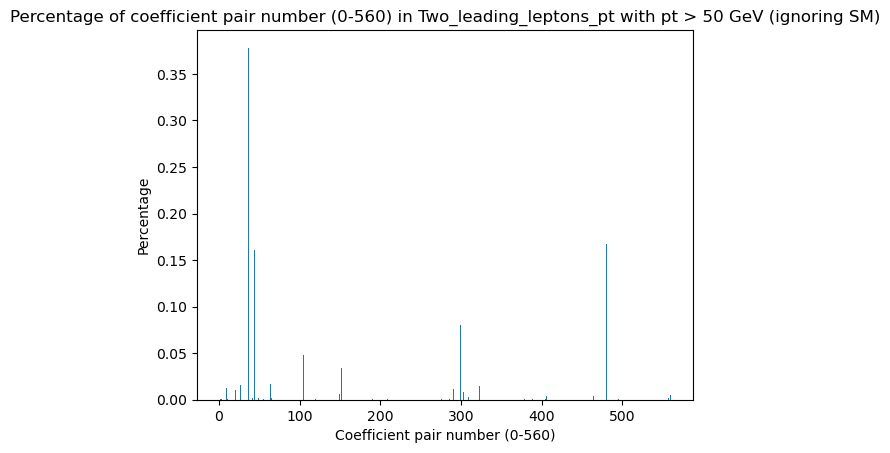

In [29]:
coefficient_histogram('Two_leading_leptons_pt',50)
plt.show()                                              # Add this line so it doesn't output other stuff lol.